# Binäre Klassifikation: Werkzeugbruch mit logistischer Regression 

**Modellklasse:** binäre multivariate logistische Regression  
**Ohne Verwendung von `sklearn`**: Training, Skalierung, Metriken, Threshold-Tuning und Vorhersagefunktion sind manuell mit `numpy`/`pandas` implementiert.

Ziel: Vorhersage von `tool_breakage` aus `depth_of_cut`, `feed_rate`, `tool_wear_min`.

In [1]:
# Standardbibliotheken laden, die wir für die manuelle logistische Regression nutzen.
# numpy für numerische Berechnungen, pandas für tabellarische Daten und matplotlib für Visualisierungen.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Pfad zur Trainingsdatei, Zielvariable und die drei Ausgangsfeatures.
# Diese Konstanten bleiben im gesamten Notebook unverändert.
DATA_PATH = "werkzeugbruch_training.csv"
TARGET = "tool_breakage"
BASE_FEATURES = ["depth_of_cut", "feed_rate", "tool_wear_min"]

# Reaktive Pandas-Warnungen für Chained Assignment deaktivieren.
pd.options.mode.chained_assignment = None

# Zufallsstart festlegen für reproduzierbare Splits und zufällige Operationen.
np.random.seed(42)

## 1. Daten laden

In [2]:
# Daten einlesen und Grundinformationen ausgeben.
# Die Datei muss sich im selben Verzeichnis befinden oder der Pfad muss angepasst werden.
df = pd.read_csv(DATA_PATH)

# Kopf der Tabelle, um ein Gefühl für die Spalten und ersten Werte zu bekommen.
print(df.head())
print("\nShape:", df.shape)
print("\nSpalten:", df.columns.tolist())
print("\nFehlende Werte:")
print(df.isna().sum())

# Statistische Kennzahlen zu den numerischen Spalten anzeigen.
df.describe()

   depth_of_cut  feed_rate  tool_wear_min  tool_breakage
0          1.22      0.191           66.7              0
1          3.46      0.254          102.8              0
2          3.23      0.183           22.8              0
3          2.89      0.280           73.4              0
4          1.62      0.314           31.5              0

Shape: (5000, 4)

Spalten: ['depth_of_cut', 'feed_rate', 'tool_wear_min', 'tool_breakage']

Fehlende Werte:
depth_of_cut     0
feed_rate        0
tool_wear_min    0
tool_breakage    0
dtype: int64


,depth_of_cut,feed_rate,tool_wear_min,tool_breakage
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,2.242140,0.278035,58.950020,0.052400
std,1.180713,0.155624,34.687123,0.222855
min,0.500000,0.050000,0.000000,0.000000
25%,1.270000,0.143000,28.400000,0.000000
50%,2.040000,0.251000,58.900000,0.000000
75%,3.072500,0.403000,88.600000,0.000000
max,4.990000,0.600000,120.000000,1.000000


## 2. Explorative Datenanalyse 

Untersucht werden Feature-Verteilungen, Klassenungleichgewicht und Zusammenhänge zwischen Prozessparametern und Werkzeugbruch.

tool_breakage
0    4738
1     262
Name: count, dtype: int64
Bruchrate: 5.24%


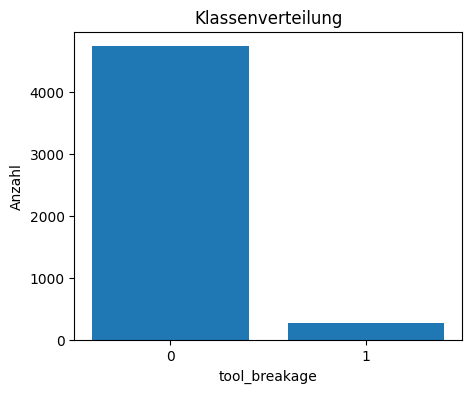

In [3]:
# Untersuchung der Klassenverteilung in der Zielvariable.
# Bei binären Klassifikationsproblemen ist das Klassenungleichgewicht oft entscheidend.
class_counts = df[TARGET].value_counts().sort_index()
breakage_rate = df[TARGET].mean()#Da die Zielvariable binär ist (0 = kein Bruch, 1 = Bruch), entspricht der Mittelwert direkt dem Anteil der Brüche.
print(class_counts)
print(f"Bruchrate: {breakage_rate:.2%}")

# Balkendiagramm zur Visualisierung der Häufigkeiten der Klassen 0 und 1.
plt.figure(figsize=(5, 4))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.xlabel("tool_breakage")
plt.ylabel("Anzahl")
plt.title("Klassenverteilung")
plt.show()

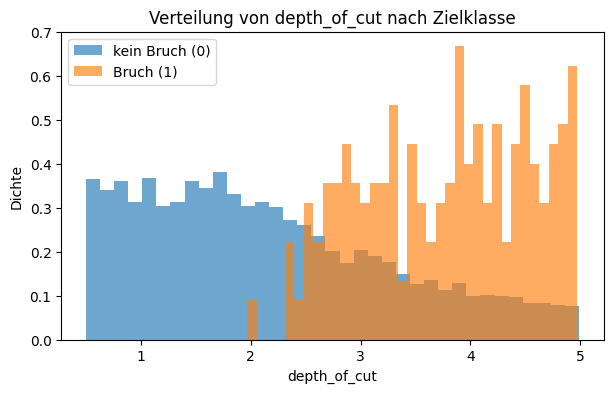

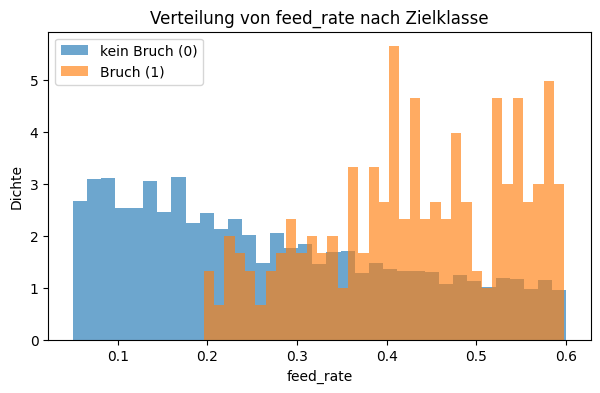

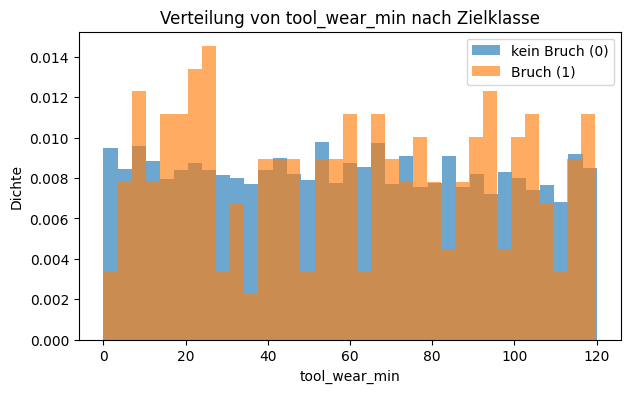

In [4]:
# Jede Ausgangsgröße einzeln betrachten, getrennt nach Zielklasse 0 vs. 1.
# Dichte-Plots zeigen, ob sich die Verteilungen der Features in den Klassen unterscheiden.
for col in BASE_FEATURES:#Die Schleife durchläuft nacheinander jedes Feature.
    plt.figure(figsize=(7, 4))
    #wählt alle Werte des aktuellen Features aus, bei denen kein Werkzeugbruch aufgetreten ist.
    plt.hist(df.loc[df[TARGET] == 0, col], bins=35, alpha=0.65, label="kein Bruch (0)", density=True)
    plt.hist(df.loc[df[TARGET] == 1, col], bins=35, alpha=0.65, label="Bruch (1)", density=True)
    plt.xlabel(col)
    plt.ylabel("Dichte")
    plt.title(f"Verteilung von {col} nach Zielklasse")
    plt.legend()
    plt.show()

               depth_of_cut  feed_rate  tool_wear_min  tool_breakage
depth_of_cut       1.000000  -0.346077      -0.022064       0.303647
feed_rate         -0.346077   1.000000      -0.013943       0.231938
tool_wear_min     -0.022064  -0.013943       1.000000       0.004347
tool_breakage      0.303647   0.231938       0.004347       1.000000


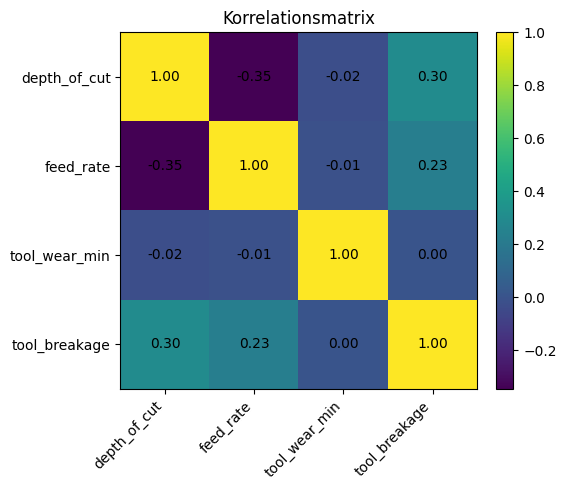

In [5]:
# Korrelationsanalyse zwischen den Ausgangsfeatures und dem Ziel.
# Diese Informationen helfen zu verstehen, welche Features linear miteinander zusammenhängen.
corr = df[BASE_FEATURES + [TARGET]].corr(numeric_only=True)
#Zunächst wird die Korrelationsmatrix berechnet.
print(corr)
#+1 → perfekter positiver Zusammenhang
#0 → kein linearer Zusammenhang
#−1 → perfekter negativer Zusammenhang
# Heatmap zur Visualisierung der Korrelationsmatrix.
plt.figure(figsize=(6, 5))
im = plt.imshow(corr.values)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Korrelationsmatrix")
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")

plt.tight_layout()
plt.show()

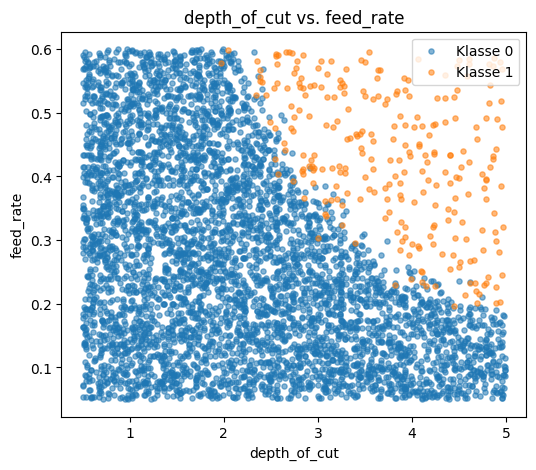

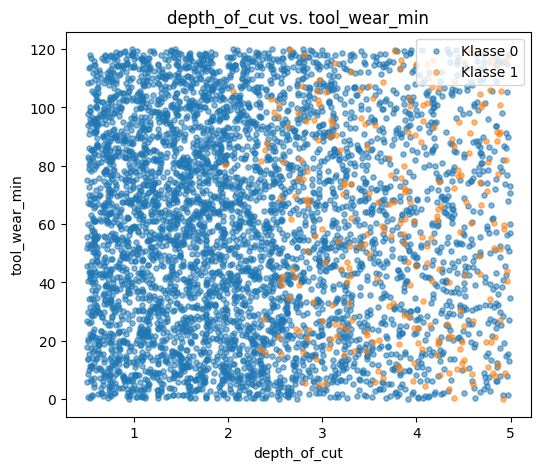

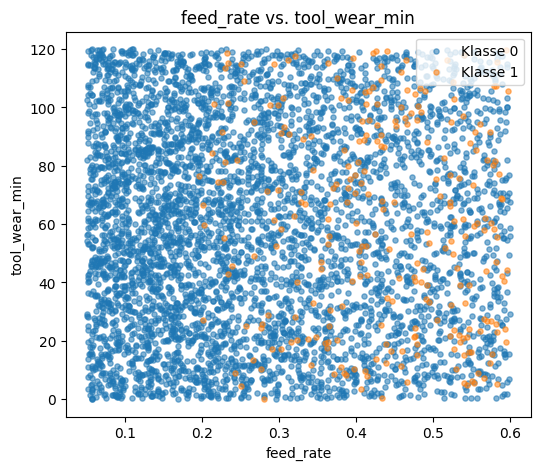

In [6]:
# Streudiagramme für die Feature-Paare im Originalraum.
# Diese Visualisierung zeigt, wie gut die Klassen 0 und 1 in den einzelnen Feature-Projektionen trennbar sind.
pairs = [("depth_of_cut", "feed_rate"), ("depth_of_cut", "tool_wear_min"), ("feed_rate", "tool_wear_min")]
for xcol, ycol in pairs:
    plt.figure(figsize=(6, 5))
    for cls in [0, 1]:
        part = df[df[TARGET] == cls]
        plt.scatter(part[xcol], part[ycol], s=14, alpha=0.55, label=f"Klasse {cls}")
    plt.xlabel(xcol)
    plt.ylabel(ycol)
    plt.title(f"{xcol} vs. {ycol}")
    plt.legend()
    plt.show()

## 3. Feature Engineering

Logistische Regression ist linear im transformierten Feature-Raum. Da Werkzeugbruch plausibel durch kombinierte Belastung entsteht, werden zusätzlich zwei Interaktionsterme gebildet:

- `depth_of_cut * feed_rate`: Spanungs-/Belastungsindikator
- `depth_of_cut * feed_rate * tool_wear_min`: Verschleiß verstärkt die Wirkung hoher Prozesslast

Das Modell bleibt eine binäre multivariate logistische Regression, arbeitet aber auf diesen erweiterten Features.

In [7]:
def make_features(data):
    """Builds two extra combined features from the three measured quantities.

    Idea: a tool breakage is caused by the interplay of load and wear,
    not by a single quantity on its own.
    """
    cut_depth = data["depth_of_cut"].to_numpy(dtype=float)
    feed      = data["feed_rate"].to_numpy(dtype=float)
    wear      = data["tool_wear_min"].to_numpy(dtype=float)

    # Two combined quantities that describe the breakage risk well.
    load           = cut_depth * feed         # how heavily the material is cut
    load_with_wear = cut_depth * feed * wear  # load multiplied by wear

    # Stack all features side by side into one matrix.
    return np.column_stack([
        cut_depth,
        feed,
        wear,
        load,
        load_with_wear,
    ])

# Plain names of the features in exactly the same order as above.
ENGINEERED_FEATURE_NAMES = [
    "depth_of_cut",
    "feed_rate",
    "tool_wear_min",
    "depth_x_feed",
    "depth_x_feed_x_wear",
]

# Quick check that the features are built correctly.
X_eng = make_features(df[BASE_FEATURES])
print(pd.DataFrame(X_eng, columns=ENGINEERED_FEATURE_NAMES).head())

   depth_of_cut  feed_rate  tool_wear_min  depth_x_feed  depth_x_feed_x_wear
0          1.22      0.191           66.7       0.23302            15.542434
1          3.46      0.254          102.8       0.87884            90.344752
2          3.23      0.183           22.8       0.59109            13.476852
3          2.89      0.280           73.4       0.80920            59.395280
4          1.62      0.314           31.5       0.50868            16.023420


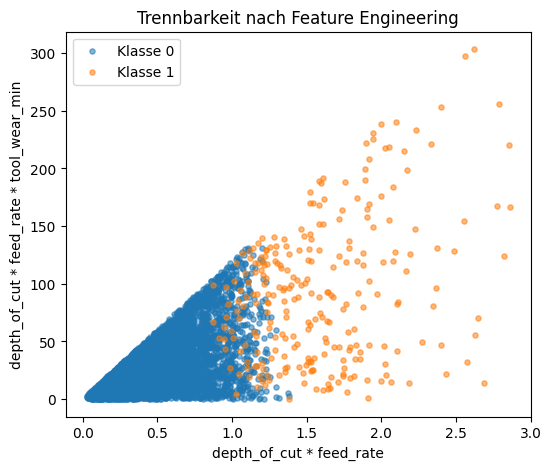

In [8]:
# Visualisierung der neuen Feature-Kombinationen nach Zielklasse.
# Wir zeigen, ob die Kombination tieferer, interaktiver Features die Klassen besser trennt.
plot_df = pd.DataFrame(X_eng, columns=ENGINEERED_FEATURE_NAMES)
plot_df[TARGET] = df[TARGET].values

plt.figure(figsize=(6, 5))
for cls in [0, 1]:
    part = plot_df[plot_df[TARGET] == cls]
    plt.scatter(part["depth_x_feed"], part["depth_x_feed_x_wear"], s=14, alpha=0.55, label=f"Klasse {cls}")
plt.xlabel("depth_of_cut * feed_rate")
plt.ylabel("depth_of_cut * feed_rate * tool_wear_min")
plt.title("Trennbarkeit nach Feature Engineering")
plt.legend()
plt.show()

## 4. Train/Validation-Split, Skalierung und Hilfsfunktionen

Die Skalierung wird manuell auf dem Trainingsdatensatz gelernt und anschließend auf Validierung und spätere Testdaten angewendet.

In [9]:
def train_val_split(data, val_fraction=0.2, seed=42):
    """Splits the data randomly into a training and a validation part."""
    rng = np.random.default_rng(seed)
    order = rng.permutation(len(data))              # shuffle the rows
    n_val = int(round(val_fraction * len(data)))    # e.g. 20% for validation

    val_rows   = order[:n_val]
    train_rows = order[n_val:]
    return (data.iloc[train_rows].reset_index(drop=True),
            data.iloc[val_rows].reset_index(drop=True))

train_df, val_df = train_val_split(df)

# Build the features from both parts and split off the target column (0/1).
X_train = make_features(train_df[BASE_FEATURES])
y_train = train_df[TARGET].to_numpy(dtype=float)
X_val   = make_features(val_df[BASE_FEATURES])
y_val   = val_df[TARGET].to_numpy(dtype=float)

# Scaling: learn mean and spread ONLY from the training data,
# so the validation set does not "see" the scale.
feature_mean = X_train.mean(axis=0)
feature_std  = X_train.std(axis=0)
feature_std[feature_std == 0] = 1.0  # avoid division by zero

def standardize(features):
    """Brings all features onto a comparable scale (mean 0, spread 1)."""
    return (features - feature_mean) / feature_std

# Put training and validation features on the same scale.
X_train = standardize(X_train)
X_val   = standardize(X_val)

print("Train:", X_train.shape, "Validation:", X_val.shape)
print("Positive class (breakages) train:", int(y_train.sum()), "valid:", int(y_val.sum()))

Train: (4000, 5) Validation: (1000, 5)
Positive class (breakages) train: 204 valid: 58


In [10]:
def sigmoid(z):
    """Turns a number into a probability between 0 and 1."""
    z = np.clip(z, -500, 500)  # cut off very large values, otherwise exp overflows
    return 1.0 / (1.0 + np.exp(-z))

def add_intercept(features):
    """Adds a column of ones at the front (the constant bias term)."""
    ones = np.ones(features.shape[0])
    return np.column_stack([ones, features])

def precision_recall_f1(y_true, y_pred):
    """Compares prediction with truth and returns the usual metrics."""
    y_true = y_true.astype(int)
    y_pred = y_pred.astype(int)

    true_positive  = int(np.sum((y_true == 1) & (y_pred == 1)))  # breakage correctly detected
    false_positive = int(np.sum((y_true == 0) & (y_pred == 1)))  # false alarm
    false_negative = int(np.sum((y_true == 1) & (y_pred == 0)))  # breakage missed
    true_negative  = int(np.sum((y_true == 0) & (y_pred == 0)))  # correctly no breakage

    # Precision: how many reported breakages are real? Recall: how many breakages do we catch?
    precision = true_positive / (true_positive + false_positive) if (true_positive + false_positive) > 0 else 0.0
    recall    = true_positive / (true_positive + false_negative) if (true_positive + false_negative) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    return {"tp": true_positive, "fp": false_positive, "fn": false_negative, "tn": true_negative,
            "precision": precision, "recall": recall, "f1": f1}

def tune_threshold(y_true, proba):
    """Tries many thresholds and keeps the one with the best F1 score."""
    
    rows = []
    for threshold in np.linspace(0.01, 0.99, 99):
        # Convert probabilities to 0/1 predictions using current threshold
        y_pred = (proba >= threshold).astype(int)
        
        # Calculate metrics for this threshold
        metrics = precision_recall_f1(y_true, y_pred)
        
        # Save threshold + metrics together
        row = {"threshold": threshold}
        row.update(metrics)
        rows.append(row)
    
    # Build a table of all results
    table = pd.DataFrame(rows)
    
    # Find the row with the best F1 score
    best_idx = table["f1"].idxmax()
    best = table.loc[best_idx].to_dict()
    
    return best, table

## 5. Logistische Regression ohne sklearn trainieren

Wegen des Klassenungleichgewichts wird eine gewichtete Binary-Cross-Entropy optimiert. Die positive Klasse erhält ein höheres Gewicht.

In [11]:
def train_logistic_regression(X, y, learning_rate=0.1, n_iter=10000, l2=0.005):
    """Learns the weights of the logistic regression via gradient descent.

    Breakages are rare. So the model does not simply ignore them, the rare
    class gets more weight in the loss.
    """
    X = add_intercept(X)              # first column = bias
    n_samples = X.shape[0]
    weights = np.zeros(X.shape[1])    # all weights start at 0

    # Give the rare class (breakage) more weight, the common one less.
    n_breakage = np.sum(y == 1)
    n_ok       = np.sum(y == 0)
    sample_weight = np.where(y == 1,
                             n_samples / (2 * n_breakage),
                             n_samples / (2 * n_ok))

    loss_history = []
    for _ in range(n_iter):
        # 1) Prediction: current breakage probability for each example.
        p = sigmoid(X @ weights)

        # 2) Measure the loss (weighted cross-entropy + small penalty for large weights).
        cross_entropy = -np.mean(sample_weight * (y * np.log(p + 1e-12) + (1 - y) * np.log(1 - p + 1e-12)))
        penalty = 0.5 * l2 * np.sum(weights[1:] ** 2)
        loss_history.append(cross_entropy + penalty)

        # 3) Compute the gradient and take a small step downhill.
        gradient = (X.T @ ((p - y) * sample_weight)) / n_samples
        gradient[1:] += l2 * weights[1:]        # penalty does not apply to the bias
        weights -= learning_rate * gradient

    return weights, np.array(loss_history)

# Train the model and print the learned numbers.
beta, losses = train_logistic_regression(X_train, y_train)
intercept_ = beta[0]    # base level (bias)
coef_ = beta[1:]        # one weight per feature

print("intercept_:", intercept_)
for name, weight in zip(ENGINEERED_FEATURE_NAMES, coef_):
    print(f"{name:25s} {weight: .6f}")

intercept_: -5.3638076674635595
depth_of_cut               1.494131
feed_rate                  0.246303
tool_wear_min             -0.680878
depth_x_feed               2.722342
depth_x_feed_x_wear        0.983680


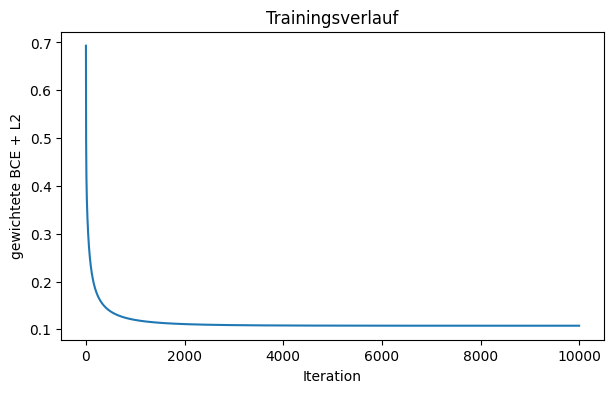

In [12]:
# Visualisierung des Trainingsverlaufs über die Iterationen.
# Dadurch sehen wir, ob der Verlust stabil sinkt und ob der Lernprozess konvergiert.
plt.figure(figsize=(7, 4))
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("gewichtete BCE + L2")
plt.title("Trainingsverlauf")
plt.show()

## 6. Evaluation und Threshold-Tuning

Threshold 0.50 validation: {'tp': 57, 'fp': 30, 'fn': 1, 'tn': 912, 'precision': 0.6551724137931034, 'recall': 0.9827586206896551, 'f1': 0.7862068965517242}

Best threshold on validation:
{'threshold': 0.8300000000000001, 'tp': 51.0, 'fp': 1.0, 'fn': 7.0, 'tn': 941.0, 'precision': 0.9807692307692307, 'recall': 0.8793103448275862, 'f1': 0.9272727272727272}


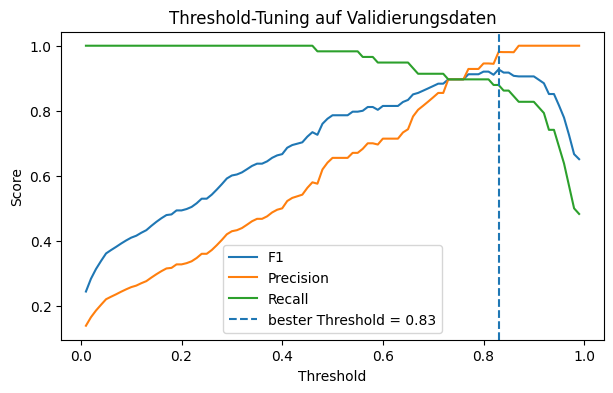

In [13]:
# Compute the breakage probability for training and validation.
train_proba = sigmoid(add_intercept(X_train) @ beta)
val_proba = sigmoid(add_intercept(X_val) @ beta)

# For comparison: result at the obvious threshold of 0.5.
print("Threshold 0.50 validation:", precision_recall_f1(y_val, (val_proba >= 0.5).astype(int)))

# Search for the best threshold by F1 on the validation data.
best_threshold_info, threshold_table = tune_threshold(y_val, val_proba)
FINAL_THRESHOLD = float(best_threshold_info["threshold"])

print("\nBest threshold on validation:")
print(best_threshold_info)

# Plot der F1-, Precision- und Recall-Kurven als Funktion des Thresholds.
plt.figure(figsize=(7, 4))
plt.plot(threshold_table["threshold"], threshold_table["f1"], label="F1")
plt.plot(threshold_table["threshold"], threshold_table["precision"], label="Precision")
plt.plot(threshold_table["threshold"], threshold_table["recall"], label="Recall")
plt.axvline(FINAL_THRESHOLD, linestyle="--", label=f"bester Threshold = {FINAL_THRESHOLD:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold-Tuning auf Validierungsdaten")
plt.legend()
plt.show()

Finale Validierungsmetriken:
{'tp': 51, 'fp': 1, 'fn': 7, 'tn': 941, 'precision': 0.9807692307692307, 'recall': 0.8793103448275862, 'f1': 0.9272727272727272}


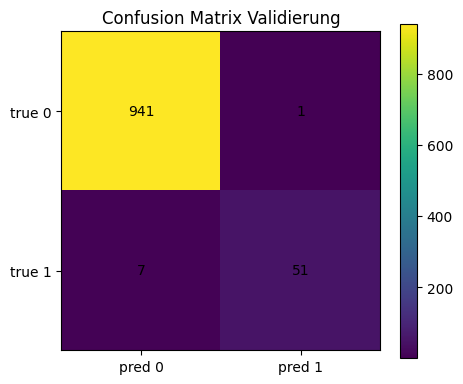

In [14]:
# Vorhersagen mit dem finalen Threshold erzeugen und auswerten.
final_val_pred = (val_proba >= FINAL_THRESHOLD).astype(int)
metrics = precision_recall_f1(y_val, final_val_pred)
print("Finale Validierungsmetriken:")
print(metrics)

# Verwirrungsmatrix zur Beurteilung von True/False Positives/Negatives.
cm = np.array([[metrics["tn"], metrics["fp"]], [metrics["fn"], metrics["tp"]]])
plt.figure(figsize=(4.8, 4))
plt.imshow(cm)
plt.xticks([0, 1], ["pred 0", "pred 1"])
plt.yticks([0, 1], ["true 0", "true 1"])
plt.title("Confusion Matrix Validierung")
plt.colorbar()
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.tight_layout()
plt.show()

## 7. Finale Vorhersagefunktion `predict_breakage(X)`

Diese Funktion akzeptiert einen beliebigen Original-DataFrame **ohne Zielvariable** mit den drei Originalspalten und gibt ein NumPy-Array mit 0/1-Vorhersagen zurück.

In [15]:
def predict_breakage_proba(X):
    """Breakage probability for new examples (input = original columns)."""
    features = make_features(X[BASE_FEATURES])  # same features as during training
    features = standardize(features)            # same scale as during training
    return sigmoid(add_intercept(features) @ beta)

def predict_breakage(X):
    """Returns 0 (no breakage) or 1 (breakage), depending on the chosen threshold."""
    proba = predict_breakage_proba(X)
    return (proba >= FINAL_THRESHOLD).astype(int)

# Quick test: the function must return a NumPy array of 0/1.
test_pred = predict_breakage(val_df[BASE_FEATURES].head())
print(type(test_pred), test_pred, test_pred.dtype, test_pred.shape)

<class 'numpy.ndarray'> [0 0 0 0 0] int64 (5,)


## 8. Koeffizienteninterpretation

Die Koeffizienten beziehen sich auf standardisierte, transformierte Features. Positive Werte erhöhen die Log-Odds für Werkzeugbruch, negative Werte senken sie.

In [16]:
# Tabelle zur Interpretation der gelernten Koeffizienten.
# abs_coef zeigt, welche Features den größten Einfluss haben, unabhängig von Vorzeichen.
coef_table = pd.DataFrame({
    "feature": ENGINEERED_FEATURE_NAMES,
    "coef": coef_,
    "abs_coef": np.abs(coef_)

}).sort_values("abs_coef", ascending=False)
coef_table

,feature,coef,abs_coef
3,depth_x_feed,2.722342,2.722342
0,depth_of_cut,1.494131,1.494131
4,depth_x_feed_x_wear,0.983680,0.983680
2,tool_wear_min,-0.680878,0.680878
1,feed_rate,0.246303,0.246303


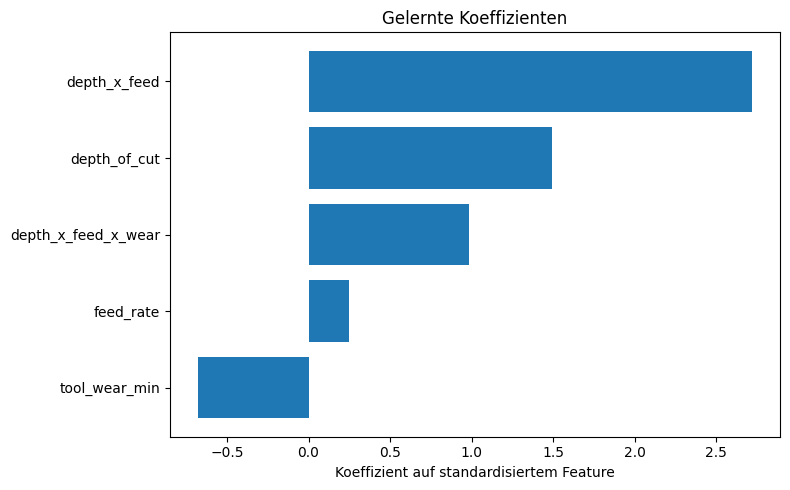

In [17]:
# Balkendiagramm zur Visualisierung der Richtung und Stärke der Koeffizienten.
plt.figure(figsize=(8, 5))
ordered = coef_table.sort_values("coef")
plt.barh(ordered["feature"], ordered["coef"])
plt.xlabel("Koeffizient auf standardisiertem Feature")
plt.title("Gelernte Koeffizienten")
plt.tight_layout()
plt.show()

**Interpretation:**

- Große positive Koeffizienten zeigen Feature-Kombinationen, die das Bruchrisiko erhöhen. Typischerweise sind Interaktionsterme mit Prozesslast und Verschleiß besonders relevant.
- Ein positiver Koeffizient bei `depth_x_feed` oder `depth_x_feed_x_wear` bedeutet: hohe Schnitttiefe und hoher Vorschub sind besonders kritisch, vor allem bei zunehmender Werkzeugstandzeit.
- Negative Koeffizienten einzelner quadratischer oder Interaktionsterme können durch Korrelationen zwischen den transformierten Features entstehen. Sie sind deshalb nicht isoliert physikalisch zu lesen, sondern im Zusammenspiel des linearen Prädiktors.
- Physikalisch passt das Modell zur Erwartung: Bruch entsteht nicht nur durch einen einzelnen Parameter, sondern durch kombinierte mechanische und verschleißbezogene Belastung.

## 9. Manuelle Implementierung und numerischer Vergleich

Da das Modell vollständig manuell implementiert ist, ist die manuelle Gleichung identisch mit der verwendeten Vorhersage. Der folgende Block zeigt explizit die Berechnung über \(p_i = \sigma(w^T x_i + b)\).

In [18]:
def manual_predict_proba_from_coef(X_scaled, coef, intercept):
    """Computes the probability by hand: p = sigmoid(x · weights + bias)."""
    z = X_scaled @ coef + intercept
    return sigmoid(z)

# Shows that the prediction function does exactly the same as the formula by hand.
proba_manual        = manual_predict_proba_from_coef(X_val, coef_, intercept_)
proba_from_function = predict_breakage_proba(val_df[BASE_FEATURES])

max_difference = np.max(np.abs(proba_manual - proba_from_function))
print("Largest difference:", max_difference)
assert max_difference < 1e-10

Largest difference: 3.3306690738754696e-16


## 10. Entscheidungsgrenze im Original-Feature-Raum

Visualisiert wird ein 2D-Schnitt: zwei Features werden variiert, das dritte Feature wird auf den Median gesetzt. Die Grenze ist dadurch im Original-Feature-Raum interpretierbar.

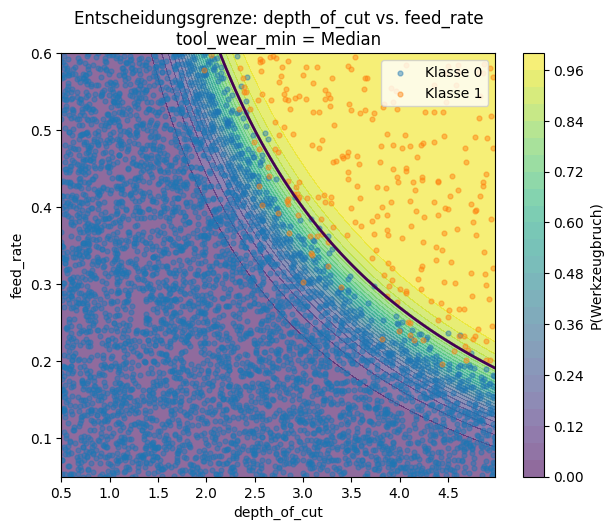

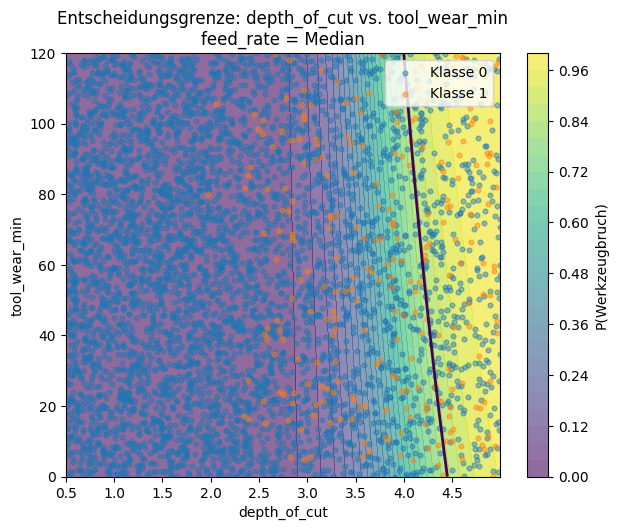

In [19]:
def plot_decision_boundary_2d(x_feature, y_feature, fixed_feature):
    """Zeigt die Klassengrenze in einem 2D-Schnitt mit festgehaltenem dritten Feature."""
    x_min, x_max = df[x_feature].min(), df[x_feature].max()
    y_min, y_max = df[y_feature].min(), df[y_feature].max()
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 180), np.linspace(y_min, y_max, 180))

    grid = pd.DataFrame({
        x_feature: xx.ravel(),
        y_feature: yy.ravel(),
        fixed_feature: np.full(xx.size, df[fixed_feature].median())
    })
    # Sicherstellen, dass die Spalten in der erwarteten Reihenfolge stehen.
    grid = grid[BASE_FEATURES]
    zz = predict_breakage_proba(grid).reshape(xx.shape)

    plt.figure(figsize=(7, 5.5))
    plt.contourf(xx, yy, zz, levels=25, alpha=0.6)
    plt.colorbar(label="P(Werkzeugbruch)")
    plt.contour(xx, yy, zz, levels=[FINAL_THRESHOLD], linewidths=2)

    for cls in [0, 1]:
        part = df[df[TARGET] == cls]
        plt.scatter(part[x_feature], part[y_feature], s=12, alpha=0.45, label=f"Klasse {cls}")

    plt.xlabel(x_feature)
    plt.ylabel(y_feature)
    plt.title(f"Entscheidungsgrenze: {x_feature} vs. {y_feature}\n{fixed_feature} = Median")
    plt.legend()
    plt.show()

# Zwei projizierte 2D-Schnitte darstellen.

plot_decision_boundary_2d("depth_of_cut", "feed_rate", "tool_wear_min")
plot_decision_boundary_2d("depth_of_cut", "tool_wear_min", "feed_rate")

## 11. Kritische Reflexion

- Das Modell ist trotz Feature Engineering nur linear im transformierten Feature-Raum. Sehr komplexe Bruchmechanismen können dadurch nur approximiert werden.
- Die Koeffizienten der Engineering-Features sind wegen Multikollinearität nicht vollständig unabhängig interpretierbar.
- Threshold-Tuning wurde auf einem Validierungssplit durchgeführt; für eine robuste Abschätzung wäre Cross-Validation oder ein separater Testdatensatz besser.
- Bei stark unausgewogenen Klassen hängt der optimale Threshold von den Kosten falscher Alarme und übersehener Brüche ab.
- Die Visualisierung der Entscheidungsgrenze ist nur ein 2D-Schnitt, während das Modell in einem höherdimensionalen transformierten Raum arbeitet.

## 12. Kurzfassung für die Präsentation

1. Problem: Werkzeugbruch ist selten, daher ist Accuracy ungeeignet.
2. EDA: deutliche Klassenimbalance; Bruchrisiko hängt nicht nur von Einzelfeatures ab.
3. Feature Engineering: Interaktionen aus Schnitttiefe, Vorschub und Werkzeugverschleiß verbessern die Trennbarkeit.
4. Modell: gewichtete logistische Regression ohne sklearn.
5. Threshold-Tuning: optimiert F1 der positiven Klasse.
6. Interpretation: kombinierte Prozesslast und Verschleiß treiben die Bruchwahrscheinlichkeit.
7. Grenzen: lineares Modell, begrenzte nichtlineare Struktur, Threshold abhängig vom Anwendungskontext.